# Cycle 3: XGBoost and a feed-forward neural network

The CatBoost experiment is preserved. This notebook reviews two new pipelines built after applying our agreed data corrections, and compares their recorded predictions on exactly the same chronological partitions.

**Saved baseline:** `outputs/snapshots/catboost_baseline_2026-10-05.zip` contains the earlier code, notebooks, data, and outputs, with a SHA-256 manifest. The original CatBoost pipeline and results remain in `outputs/catboost/`.

**Run mode:** the experiments have already been executed. By default, this notebook reads their saved results and reproduces the comparison plots. Set `RUN_TRAINING = True` below to rerun both new experiments from their source modules. It never retrains or overwrites the CatBoost baseline.

September-October has already been examined during the CatBoost cycle. It is a **reused comparison period**, not a fresh untouched test set. Model settings and stopping points for these new experiments were chosen on July-August only.

In [1]:
%matplotlib inline
from pathlib import Path
import sys, json, hashlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'comparison_common.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Start this notebook inside the spotter project.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from comparison_common import make_preprocessor, regression_report, verified_splits, NUMERIC_FEATURES
from freight_model import CORE_COLUMNS, COORDINATES, source_hashes, split_summary
OUT = ROOT/'outputs'/'comparison'
OUT.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi':110, 'axes.titleweight':'bold'})
COLORS = {'Baseline':'#9ba6ae', 'CatBoost':'#007f86', 'XGBoost':'#ba812f', 'FFN':'#7958a7'}
RUN_TRAINING = False

cat_meta = json.loads((ROOT/'outputs/catboost/metadata.json').read_text())
original_hashes = source_hashes(ROOT)
assert original_hashes == cat_meta['source_sha256']
manifest_path = ROOT/'outputs/snapshots/catboost_baseline_2026-10-05_manifest.json'
manifest = json.loads(manifest_path.read_text())
protected = {name: digest for name,digest in manifest.items() if name.startswith('outputs/catboost/') or name in ['freight_model.py','notebooks/01_data_exploration.ipynb','notebooks/02_catboost_pipeline.ipynb','tests/test_freight_model.py']}
def verify_preservation():
    for name, digest in protected.items():
        assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest() == digest, name
    assert source_hashes(ROOT) == original_hashes
verify_preservation()
print(f'Preserved baseline verified: {len(protected)} protected files and all four source CSVs.')

Preserved baseline verified: 22 protected files and all four source CSVs.


## 1. Reuse the exact split before learning any preprocessing

- **Train:** January-June, 28,806 loads.
- **Development:** July-August, 9,671 loads. Chooses settings and trees/epochs.
- **Comparison test:** September-October, 9,523 loads.

The split manifest must match the saved CatBoost run. After choosing a model, every learned preprocessing step and model is fitted again on January-August, with the chosen tree/epoch count frozen. September-October is never supplied to early stopping. The external `validation.csv` still has no target prices.

In [2]:
splits = verified_splits(ROOT)
display(split_summary(splits))

,split,rows,percent,first_date,last_date,missing_weight,negative_weight
0,train,28806,60.012500,2025-01-01,2025-06-30,177,196
1,dev,9671,20.147917,2025-07-01,2025-08-31,58,37
2,test,9523,19.839583,2025-09-01,2025-10-31,65,59


## 2. What “fixing the data” means here

| Input | XGBoost | FFN |
|---|---|---|
| Negative weight | Absolute value, original-sign flag retained | Same |
| Missing numerical values | Training median, missing-weight flag retained | Same, then numerical scaling |
| City/equipment categories | Training-fitted one-hot encoding | Same |
| Unseen category | All-zero block for that category | Same |
| Latitude/longitude | Separate numerical features; training city lookup fills absent known coordinates | Same |
| Date | Days since training start, weekday, day of month | Same, scaled with other numerical features |
| Target price | Train directly in total dollars | Standardize using training targets; invert predictions back to dollars |

A median is a **replacement estimate**, not the recovered true value. If a city is unseen and coordinates are also absent, the lookup cannot recover its position: numerical imputation uses training medians. Those fallback coordinates do not identify the real city. Supplied coordinates are retained.

No source CSV is edited. No price outliers are deleted or clipped. The same 14 source-derived features are used across all three families; one-hot encoding expands them to 142 numerical columns here. `load_id`, prices/output placeholders, `quote_signal`, and `market_index` remain excluded. CatBoost's existing native-null/categorical handling is preserved; we are comparing complete pipelines, not isolating only the algorithm.

The shared implementation is `comparison_common.py`. Imputers, category vocabularies, feature scalers, and FFN target scalers learn only from the fitting rows. [scikit-learn preprocessing guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)

In [3]:
# Audit a train-only preprocessor without training another predictive model.
preview = make_preprocessor(scale=False)
clean_train = preview.fit_transform(splits['train'])
prepared = preview.named_steps['features'].transform(splits['train'])
imputer = preview.named_steps['encode'].named_transformers_['numeric'].named_steps['impute']
audit = pd.DataFrame({'feature':NUMERIC_FEATURES,
                      'missing_before_imputation':[int(prepared[c].isna().sum()) for c in NUMERIC_FEATURES],
                      'training_median':imputer.statistics_})
display(audit)
assert np.isfinite(clean_train).all()
print('Clean training matrix:', clean_train.shape)
print('The displayed medians are learned from January-June only; final refits learn fresh January-August values.')

,feature,missing_before_imputation,training_median
0,distance,0,954.60000
1,weight,177,31477.00000
2,weight_is_missing,0,0.00000
3,weight_was_negative,0,0.00000
4,pickup_lat,0,35.29479
5,pickup_lon,0,-88.08915
6,delivery_lat,0,35.29479
7,delivery_lon,0,-87.52871
8,days_since_start,0,90.00000
9,day_of_week,0,3.00000


Clean training matrix: (28806, 142)
The displayed medians are learned from January-June only; final refits learn fresh January-August values.


## 3. The model experiments

**XGBoost:** three candidates: depth 4 with absolute-error loss, depth 6 with absolute-error loss, and depth 4 with squared-error loss. All use learning rate 0.05, up to 1,200 boosting rounds, and patience 100. The external development set controls early stopping using MAE. The selected tree count is `best_iteration + 1`. [XGBoost early stopping](https://xgboost.readthedocs.io/en/stable/python/sklearn_estimator.html)

**FFN:** a genuine fully connected neural network implemented with `MLPRegressor`. It uses ReLU hidden layers, Adam, squared-error training loss, batch size 256, and learning rate 0.001. Candidates are hidden layers `(64, 32)` or `(128, 64)` with L2 penalty 0.001, plus `(64, 32)` with penalty 0.01. An epoch is one pass through the training rows.

Up to 200 epochs are allowed with patience 25. Each epoch uses `partial_fit`, preserving Adam state. We measure development MAE **after converting predictions back into dollars**, retain a copy of the best checkpoint, then refit a fresh model on January-August for that fixed epoch count. Built-in random validation splitting is disabled. Shuffling batches inside the training period does not mix chronological partitions. [MLPRegressor documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)

All families use seed 42 and the same positive prediction floor of $0.01. These small candidate searches are starting experiments, not an exhaustive claim about either model family.

In [4]:
if RUN_TRAINING:
    from xgboost_experiment import run_experiment as run_xgboost
    from ffn_experiment import run_experiment as run_ffn
    run_xgboost(ROOT)
    run_ffn(ROOT)
else:
    print('Reading completed experiments; no predictive models are being retrained.')

folders = {'CatBoost':ROOT/'outputs/catboost', 'XGBoost':ROOT/'outputs/xgboost', 'FFN':ROOT/'outputs/ffn'}
metadata = {name:json.loads((folder/'metadata.json').read_text()) for name,folder in folders.items()}
for name,meta in metadata.items():
    assert meta['source_sha256'] == original_hashes
    assert meta['saved_model_fit_end'] == '2025-08-31'
    assert meta['saved_model_fit_rows'] == 38477

settings = pd.DataFrame([
    {'model':'CatBoost','chosen_configuration':metadata['CatBoost']['selected_model'],'training_length':f"{metadata['CatBoost']['selected_trees']} trees"},
    {'model':'XGBoost','chosen_configuration':metadata['XGBoost']['selected_model'],'training_length':f"{metadata['XGBoost']['selected_rounds']} trees"},
    {'model':'FFN','chosen_configuration':metadata['FFN']['selected_model'],'training_length':f"{metadata['FFN']['selected_epochs']} epochs"},
])
display(settings)
for name in ['XGBoost','FFN']:
    display(Markdown(f'**{name}: all development candidates**'))
    display(pd.read_csv(folders[name]/'dev_metrics.csv').round(3))

Reading completed experiments; no predictive models are being retrained.


,model,chosen_configuration,training_length
0,CatBoost,CatBoost depth 6 MAE,94 trees
1,XGBoost,XGBoost depth 4 MAE,81 trees
2,FFN,FFN 128-64 alpha .001,2 epochs


**XGBoost: all development candidates**

,model,rounds,seconds,MAE,RMSE,R2,bias,median_absolute_error,MAPE_percent,within_5_percent,within_10_percent,within_20_percent
0,XGBoost depth 4 MAE,81,2.437,135.368,625.463,0.824,12.860,66.999,6.960,66.001,91.138,97.446
1,XGBoost depth 6 MAE,67,1.570,149.070,625.876,0.824,41.903,85.945,8.049,53.635,84.986,96.960
2,XGBoost depth 4 squared error,52,1.186,179.911,634.641,0.819,63.355,118.376,10.799,44.215,71.999,91.159
3,Equipment median baseline,0,0.000,222.731,662.875,0.802,40.758,113.270,10.106,39.076,67.976,93.434


**FFN: all development candidates**

,model,epochs,epochs_run,seconds,MAE,RMSE,R2,bias,median_absolute_error,MAPE_percent,within_5_percent,within_10_percent,within_20_percent
0,FFN 128-64 alpha .001,2,27,3.374,284.580,675.615,0.795,179.672,188.663,14.190,26.357,52.404,85.668
1,FFN 64-32 alpha .01,4,29,2.204,290.681,671.312,0.797,194.011,216.415,15.319,23.028,47.916,82.732
2,FFN 64-32 alpha .001,4,29,2.217,290.937,671.793,0.797,193.421,215.050,15.244,23.172,48.154,83.073


## 4. Learning curves explain the stopping decisions

Lower development MAE is better. Later trees or epochs can continue reducing training loss while making later-month predictions worse. A best checkpoint at an early epoch is valid: the experiment ran beyond it to check for improvement. The FFN chart deliberately uses dollar MAE, not its scaled training loss, so the plotted quantity matches model selection.

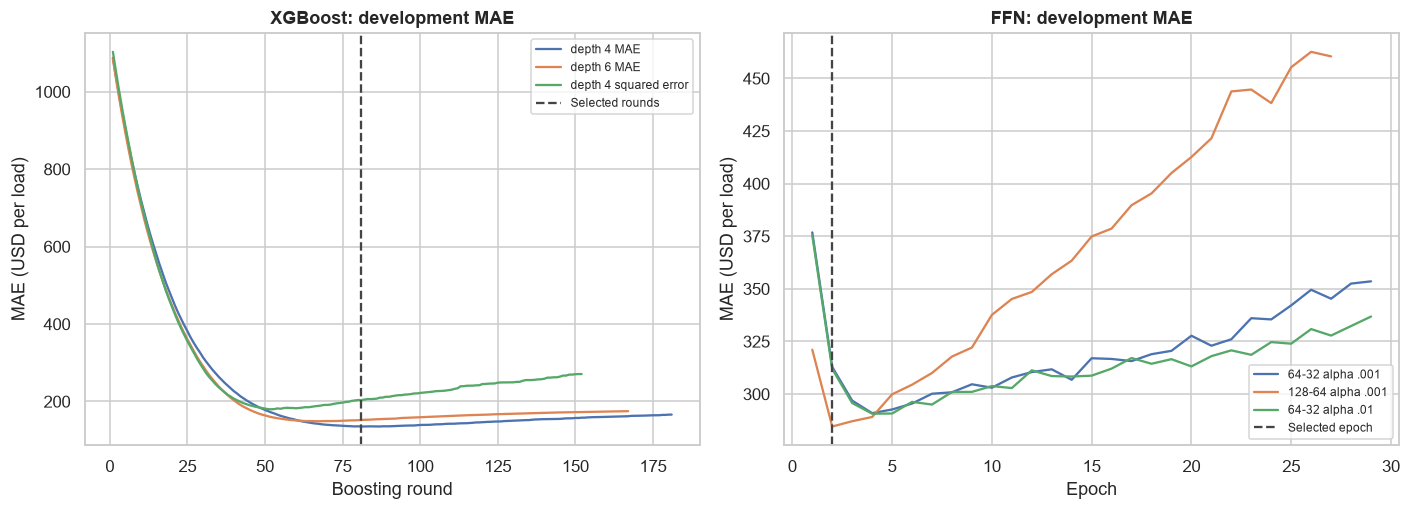

In [5]:
fig, axes = plt.subplots(1,2,figsize=(13,4.8))
xhist = json.loads((folders['XGBoost']/'learning_curves.json').read_text())
fhist = json.loads((folders['FFN']/'learning_curves.json').read_text())
for name,h in xhist.items():
    values = h['validation_1']['mae']
    axes[0].plot(np.arange(1,len(values)+1),values,label=name.replace('XGBoost ',''))
axes[0].axvline(metadata['XGBoost']['selected_rounds'],color='#444444',linestyle='--',label='Selected rounds')
for name,records in fhist.items():
    h = pd.DataFrame(records)
    axes[1].plot(h['epoch'],h['dev_MAE'],label=name.replace('FFN ',''))
axes[1].axvline(metadata['FFN']['selected_epochs'],color='#444444',linestyle='--',label='Selected epoch')
for ax,title,xlabel in zip(axes,['XGBoost: development MAE','FFN: development MAE'],['Boosting round','Epoch']):
    ax.set(title=title,xlabel=xlabel,ylabel='MAE (USD per load)')
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT/'learning_curves.png',dpi=150,bbox_inches='tight')
plt.show()

## 5. Compare saved predictions on identical rows

We recompute every metric from saved row-level predictions and verify the row IDs and actual prices against the source partitions.

- **MAE/RMSE:** dollar errors; lower is better. RMSE gives large mistakes more influence.
- **MAPE:** average absolute percentage error, with each row's actual price as denominator. It can be strongly affected by cheap loads.
- **Within 5% / 10% / 20%:** fraction of predictions whose absolute relative error is no greater than that tolerance. These are explicitly defined acceptance rates, not a universal classification accuracy.
- **R2:** explained variation, not percentage accuracy.

The baseline is the same equipment median price-per-mile model used earlier. Development results chose configurations; test results describe their later-period behavior.

**Development: January-June fit**

,model,MAE,RMSE,R2,bias,MAPE_percent,within_5_percent,within_10_percent,within_20_percent
1,XGBoost,135.368,625.463,0.824,12.860,6.960,66.001,91.138,97.446
0,CatBoost,155.659,627.943,0.823,51.361,8.257,57.181,91.769,96.536
3,Baseline,222.731,662.875,0.802,40.758,10.106,39.076,67.976,93.434
2,FFN,284.580,675.615,0.795,179.672,14.190,26.357,52.404,85.668


**Reused test: January-August refit**

,model,MAE,RMSE,R2,bias,MAPE_percent,within_5_percent,within_10_percent,within_20_percent
4,CatBoost,128.077,643.243,0.822,-67.037,6.615,83.829,94.897,96.377
5,XGBoost,130.535,639.584,0.824,-47.780,6.480,74.682,93.804,97.259
6,FFN,180.804,644.253,0.822,7.585,9.671,50.068,77.759,93.521
7,Baseline,229.097,670.660,0.807,40.929,10.487,38.465,67.384,92.681


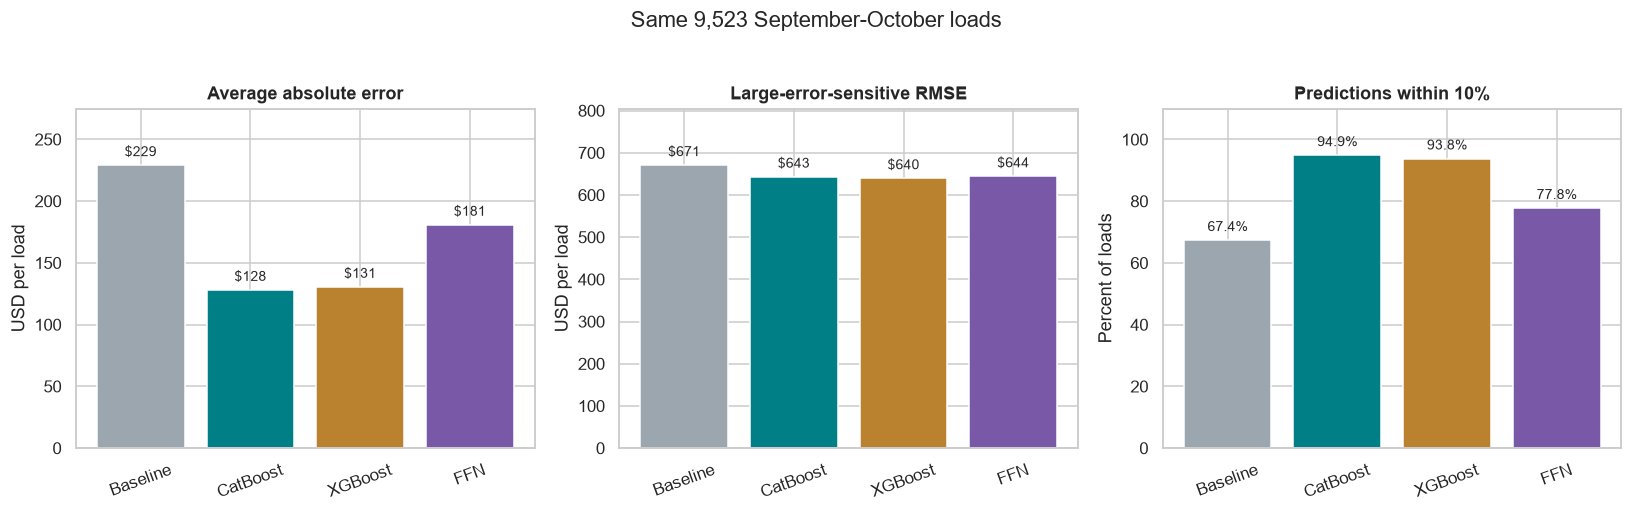

In [6]:
predictions = {}
metric_rows = []
for phase in ['dev','test']:
    truth = splits[phase].set_index('load_id')['posted_rate'].sort_index()
    for name,folder in folders.items():
        p = pd.read_csv(folder/f'{phase}_predictions.csv',parse_dates=['date']).set_index('load_id').sort_index()
        pd.testing.assert_index_equal(p.index,truth.index)
        np.testing.assert_allclose(p['posted_rate'],truth,rtol=0,atol=1e-10)
        predictions[(phase,name)] = p
        metric_rows.append({'phase':phase,'model':name,'rows':len(p),**regression_report(p['posted_rate'],p['predicted_rate'])})
    p = predictions[(phase,'CatBoost')]
    metric_rows.append({'phase':phase,'model':'Baseline','rows':len(p),**regression_report(p['posted_rate'],p['baseline_prediction'])})
metrics = pd.DataFrame(metric_rows)
metrics.to_csv(OUT/'comparison_metrics.csv',index=False)
columns = ['model','MAE','RMSE','R2','bias','MAPE_percent','within_5_percent','within_10_percent','within_20_percent']
for phase,title in [('dev','Development: January-June fit'),('test','Reused test: January-August refit')]:
    display(Markdown(f'**{title}**'))
    display(metrics.loc[metrics.phase.eq(phase),columns].sort_values('MAE').round(3))

order = ['Baseline','CatBoost','XGBoost','FFN']
test_scores = metrics.query("phase == 'test'").set_index('model').loc[order]
dev_scores = metrics.query("phase == 'dev'").set_index('model')
fig,axes = plt.subplots(1,3,figsize=(15,4.5))
for ax,column,title in zip(axes,['MAE','RMSE','within_10_percent'],['Average absolute error','Large-error-sensitive RMSE','Predictions within 10%']):
    values=test_scores[column]
    bars=ax.bar(order,values,color=[COLORS[n] for n in order])
    labels=[f'{v:.1f}%' if column=='within_10_percent' else f'${v:.0f}' for v in values]
    ax.bar_label(bars,labels=labels,padding=4,fontsize=9)
    ax.set(title=title,ylabel='Percent of loads' if column=='within_10_percent' else 'USD per load')
    ax.set_ylim(0,110 if column=='within_10_percent' else values.max()*1.2)
    ax.tick_params(axis='x',rotation=20)
fig.suptitle('Same 9,523 September-October loads',y=1.03)
fig.tight_layout()
fig.savefig(OUT/'model_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

## 6. Check consistency across months and missing weights

An overall improvement can hide a weaker month or subgroup. The following charts reuse recorded predictions; they do not fit new models or change the selection. Small subgroups are less stable. The missing-weight table compares complete pipelines and does not by itself isolate the causal benefit of imputation.

,model,group,rows,MAE,RMSE,within_10_percent
5,CatBoost,missing,65,120.929,170.084,95.385
6,CatBoost,observed,9458,128.126,645.295,94.893
12,XGBoost,missing,65,83.907,115.040,98.462
13,XGBoost,observed,9458,130.855,641.707,93.772
19,FFN,missing,65,205.976,258.142,58.462
20,FFN,observed,9458,180.631,646.109,77.892


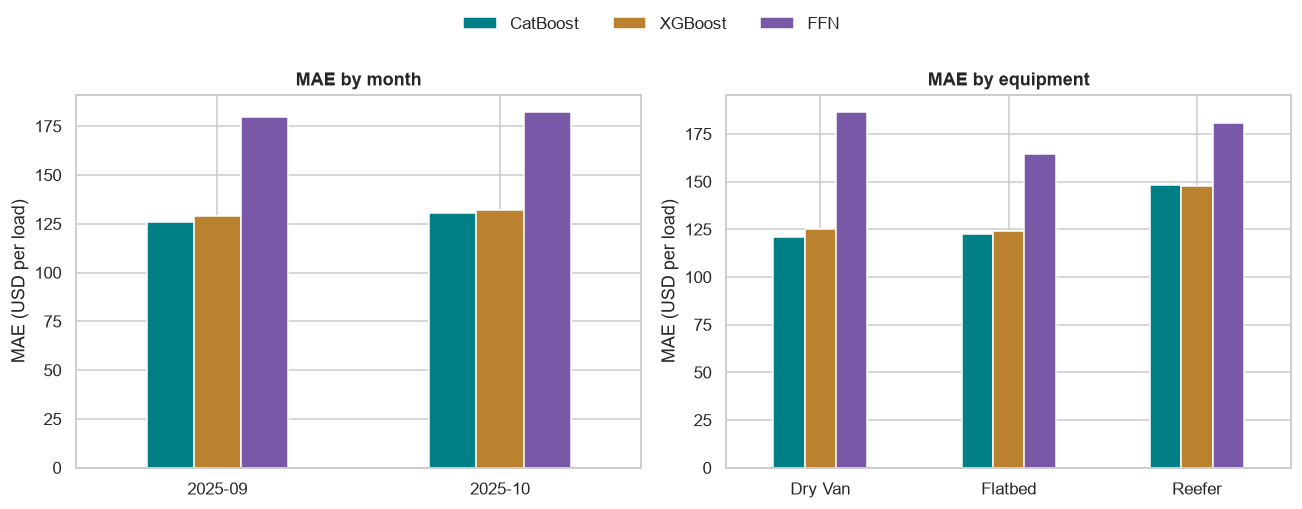

In [7]:
slice_rows=[]
for name in folders:
    p=predictions[('test',name)]
    for dimension,groups in [('month',p['date'].dt.strftime('%Y-%m')),('equipment',p['equipment']),('weight_missing',p['weight_is_missing'].map({True:'missing',False:'observed'}))]:
        for group,part in p.groupby(groups,sort=True):
            slice_rows.append({'model':name,'dimension':dimension,'group':str(group),'rows':len(part),**regression_report(part['posted_rate'],part['predicted_rate'])})
slices=pd.DataFrame(slice_rows)
slices.to_csv(OUT/'comparison_slices.csv',index=False)
display(slices.query("dimension == 'weight_missing'")[['model','group','rows','MAE','RMSE','within_10_percent']].round(3))
fig,axes=plt.subplots(1,2,figsize=(12,4.6))
for ax,dimension,title in zip(axes,['month','equipment'],['MAE by month','MAE by equipment']):
    table=slices.query('dimension == @dimension').pivot(index='group',columns='model',values='MAE').reindex(columns=list(folders))
    table.plot.bar(ax=ax,color=[COLORS[n] for n in folders],legend=False,rot=0)
    ax.set(title=title,xlabel='',ylabel='MAE (USD per load)')
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,1.02),ncols=3,frameon=False)
fig.tight_layout(rect=(0,0,1,.92))
fig.savefig(OUT/'model_comparison_by_group.png',dpi=150,bbox_inches='tight')
plt.show()

## 7. Load the saved pipelines and verify prediction behavior

Each saved joblib pipeline accepts raw named columns and applies its own fitted cleaning/encoding/scaling. The FFN also reverses target standardization internally, so its output is in dollars.

The December file checks compatibility with its reduced schema. It has no true prices, so a successful prediction call cannot establish December accuracy. We do not write submission predictions in this cycle.

In [8]:
artifact_paths={'CatBoost':folders['CatBoost']/'catboost_pipeline.joblib','XGBoost':folders['XGBoost']/'pipeline.joblib','FFN':folders['FFN']/'pipeline.joblib'}
raw_examples=splits['test'].head(8)
december=pd.read_csv(ROOT/'december-chart-inputs.csv')
checks=[]
for name,path in artifact_paths.items():
    pipeline=joblib.load(path)
    values=pipeline.predict(raw_examples[CORE_COLUMNS+COORDINATES])
    saved=predictions[('test',name)].loc[raw_examples['load_id'],'predicted_rate'].to_numpy()
    np.testing.assert_allclose(values,saved,rtol=0,atol=1e-8)
    before=december.copy(deep=True)
    future=pipeline.predict(december[CORE_COLUMNS])
    assert np.isfinite(future).all() and (future>0).all() and len(future)==31
    pd.testing.assert_frame_equal(december,before)
    checks.append({'model':name,'reload_predictions_match':True,'december_rows':len(future),'finite_positive':True})
display(pd.DataFrame(checks))
verify_preservation()
print('Existing CatBoost files and source CSV hashes are unchanged.')

,model,reload_predictions_match,december_rows,finite_positive
0,CatBoost,True,31,True
1,XGBoost,True,31,True
2,FFN,True,31,True


Existing CatBoost files and source CSV hashes are unchanged.


## 8. Interpret this bounded comparison

Model selection and model evaluation have different roles. We choose configurations by development MAE, then describe how the frozen choices behave on later rows. A different test ranking does not justify repeatedly tuning against the same test period.

Both new models were refitted using January-August data, just like the saved CatBoost. These experiments cover three candidates per family and one seed. They do not prove that all neural networks or all boosting configurations behave this way. There are no unseen cities in the local periods, and November-December prices remain hidden. More robust conclusions would require additional chronological validation windows and an evaluation plan established before further tuning.

In [9]:
best_dev=dev_scores.loc[list(folders),'MAE'].idxmin()
best_test_mae=test_scores.loc[list(folders),'MAE'].idxmin()
best_test_rmse=test_scores.loc[list(folders),'RMSE'].idxmin()
display(Markdown(
    f"**Development MAE favors {best_dev}** at ${dev_scores.loc[best_dev,'MAE']:,.2f}. "
    f"On the reused test period, **{best_test_mae} has the lowest MAE** "
    f"(${test_scores.loc[best_test_mae,'MAE']:,.2f}) and **{best_test_rmse} has the lowest RMSE** "
    f"(${test_scores.loc[best_test_rmse,'RMSE']:,.2f}). "
    "These rankings answer different questions; all three saved solutions are retained."
))
summary={'development_MAE_leader':best_dev,'reused_test_MAE_leader':best_test_mae,'reused_test_RMSE_leader':best_test_rmse,
         'rows_per_test_model':9523,'evaluation_period':'2025-09-01 through 2025-10-31',
         'preserved_snapshot':'outputs/snapshots/catboost_baseline_2026-10-05.zip',
         'source_sha256':original_hashes,'protected_baseline_files_verified':len(protected),
         'evaluation_status':'Reused comparison period already examined in prior CatBoost cycle; not a fresh holdout.'}
(OUT/'comparison_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
verify_preservation()
print('Saved comparison tables, plots, and summary to',OUT)

**Development MAE favors XGBoost** at $135.37. On the reused test period, **CatBoost has the lowest MAE** ($128.08) and **XGBoost has the lowest RMSE** ($639.58). These rankings answer different questions; all three saved solutions are retained.

Saved comparison tables, plots, and summary to C:\Users\default.LAPTOP-H1OG6SJ2\Desktop\Projects\spotter\outputs\comparison
